# Bank Customer Churn — Outlier Detection

This notebook checks the cleaned dataset (`Bank_Churn_Fully_Cleaned(pandas).csv`) for
statistical outliers across all numeric columns using the IQR method, then decides —
with reasoning — whether each flagged group should be treated as an error or kept as
legitimate data.


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
df1 = pd.read_csv('Bank_Churn_Fully_Cleaned(pandas).csv')

In [14]:
df1.shape

(10000, 13)

In [15]:
df1.head()

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,15634602,Hargrave,619,France,Female,42.0,2,0.00,1,1,1,101348.88,1
1,15647311,Hill,608,Spain,Female,41.0,1,83807.86,1,0,1,112542.58,0
2,15619304,Onio,502,France,Female,42.0,8,159660.80,3,1,0,113931.57,1
3,15701354,Boni,699,France,Female,39.0,1,0.00,2,0,0,93826.63,0
4,15737888,Mitchell,850,Spain,Female,43.0,2,125510.82,1,1,1,79084.10,0


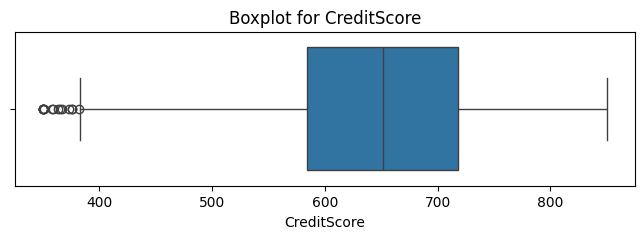

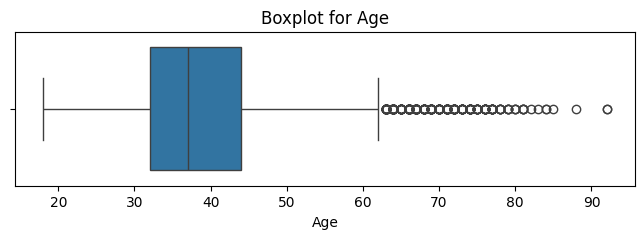

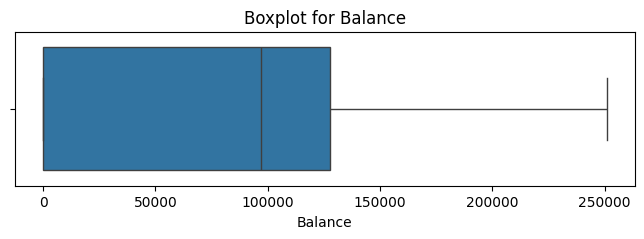

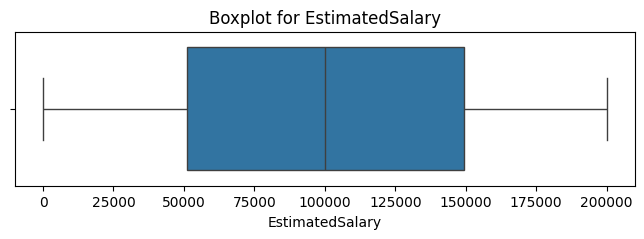

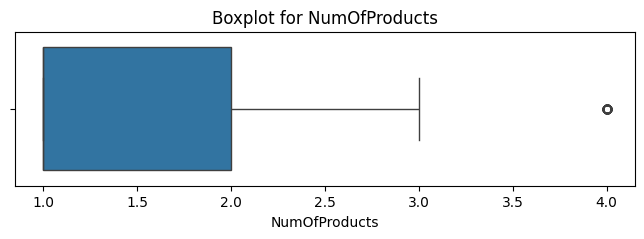

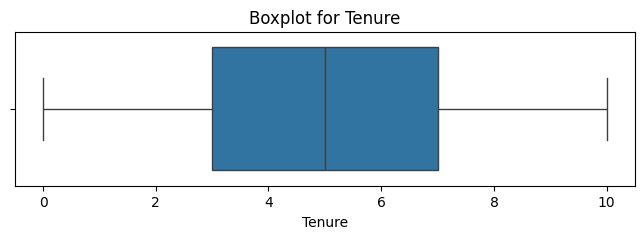

In [16]:
num_cols = ['CreditScore', 'Age', 'Balance', 'EstimatedSalary', 'NumOfProducts', 'Tenure']

for col in num_cols:
    plt.figure(figsize=(8, 2))
    sns.boxplot(x=df1[col])
    plt.title(f'Boxplot for {col}')
    plt.show()

## Sanity Check: Value Ranges

Before running IQR outlier detection, confirm there are no disguised sentinel values
(e.g. `-999999`) hiding in any numeric column — a common trap when a dataset has been
through prior cleaning.

In [17]:
df1[num_cols].agg(['min', 'max'])

,CreditScore,Age,Balance,EstimatedSalary,NumOfProducts,Tenure
min,350,18.0,0.00,11.58,1,0
max,850,92.0,250898.09,199992.48,4,10


No disguised negative sentinels remain — `EstimatedSalary` and `Balance` both have a
sensible minimum of 0 or above, confirming the earlier cleaning stage worked correctly.

In [18]:
outlier_summary = {}

for col in num_cols:
    Q1 = df1[col].quantile(0.25)
    Q3 = df1[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outlier_val = df1[(df1[col] < lower_bound) | (df1[col] > upper_bound)]
    outlier_summary[col] = len(outlier_val)
    print(f'{col}: {len(outlier_val)} outliers (bounds: {lower_bound:.2f} to {upper_bound:.2f})')

CreditScore: 15 outliers (bounds: 383.00 to 919.00)
Age: 359 outliers (bounds: 14.00 to 62.00)
Balance: 0 outliers (bounds: -191466.36 to 319110.60)
EstimatedSalary: 0 outliers (bounds: -96577.10 to 296967.45)
NumOfProducts: 60 outliers (bounds: -0.50 to 3.50)
Tenure: 0 outliers (bounds: -3.00 to 13.00)


### Logic for Handling Each Flagged Column

- **CreditScore** (15 outliers, all on the low end, below ~383): Credit scores below
  350 are real — the dataset's valid range is 300–850. These are genuinely low-credit
  customers, not data errors. **Keep.**
- **Age** (359 outliers, all above ~62): Older bank customers are common and expected.
  Flagging everyone over 62 as an "outlier" is a statistical artifact of the IQR method
  on a right-skewed distribution, not evidence of bad data. **Keep.**
- **NumOfProducts** (60 outliers, all equal to 4): This is the maximum valid value in
  the schema (1–4 products). A customer holding 4 products is unusual but plausible.
  **Keep.**
- **Balance** and **EstimatedSalary**: 0 outliers — consistent with the earlier cleaning
  stage having already resolved the hidden `-999999` sentinel issue.

Not a single flagged value here represents a genuine data error — this is expected,
since the dataset was already fully reconciled against a trusted reference in the
previous cleaning stage. This cell exists to *prove* that, not to assume it.

In [19]:
# Inspect the flagged Age values directly rather than blindly trusting the count
Q1 = df1['Age'].quantile(0.25)
Q3 = df1['Age'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR

df1[df1['Age'] > upper_bound][['CustomerId', 'Surname', 'Age', 'Balance', 'Exited']].head(10)

,CustomerId,Surname,Age,Balance,Exited
58,15623944,T'ien,66.0,0.00,1
85,15805254,Ndukaku,75.0,0.00,0
104,15804919,Dunbabin,65.0,0.00,1
158,15589975,Maclean,73.0,97259.25,0
181,15789669,Hsia,65.0,0.00,0
230,15808473,Ringrose,72.0,0.00,0
234,15704769,Smith,67.0,113978.97,0
243,15596175,McIntosh,67.0,117411.60,1
252,15793726,Matveyeva,79.0,0.00,0
310,15712287,Pokrovskii,80.0,0.00,0


In [20]:
# Inspect the flagged CreditScore values
lower_bound = df1['CreditScore'].quantile(0.25) - 1.5 * (df1['CreditScore'].quantile(0.75) - df1['CreditScore'].quantile(0.25))
df1[df1['CreditScore'] < lower_bound][['CustomerId', 'Surname', 'CreditScore', 'Exited']]

,CustomerId,Surname,CreditScore,Exited
7,15656148,Obinna,376,1
942,15804586,Lin,376,1
1193,15779947,Thomas,363,1
1405,15612494,Panicucci,359,1
1631,15685372,Azubuike,350,1
1838,15758813,Campbell,350,1
1962,15692416,Aikenhead,358,1
2473,15679249,Chou,351,1
2579,15597896,Ozoemena,365,1
8154,15791533,Ch'ien,367,1


## Conclusion

Unlike the raw messy file, this cleaned dataset requires **no outlier removal**. Every
flagged value inspected above is a legitimate, plausible customer record. Statistical
outlier detection is a *diagnostic* step — it doesn't automatically mean deleting rows;
here it confirms the dataset is sound.

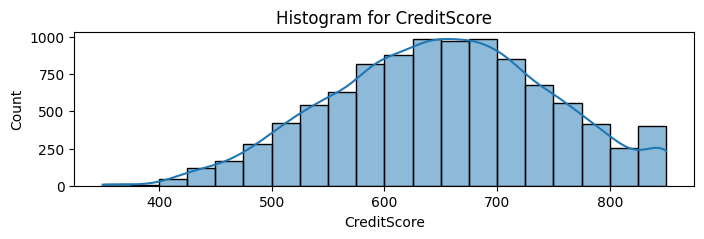

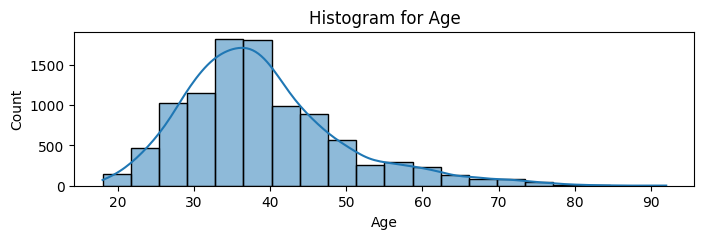

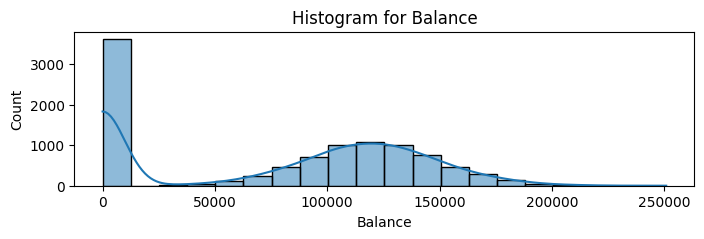

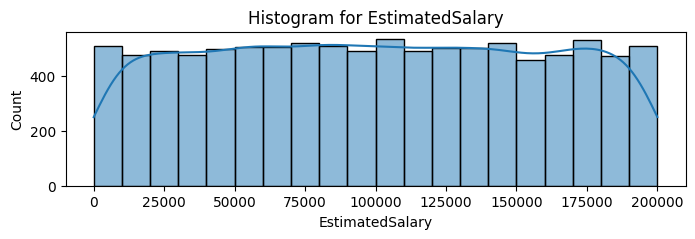

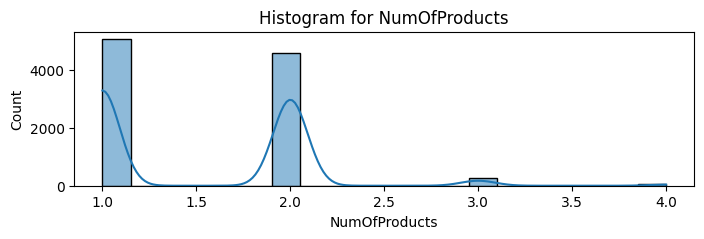

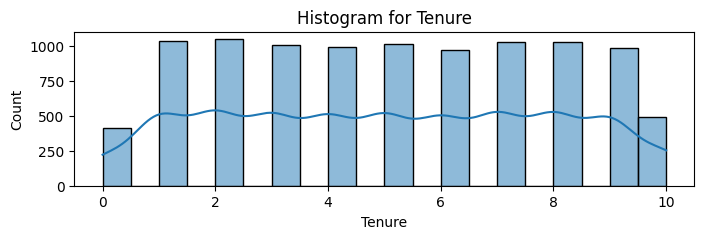

In [21]:
for col in num_cols:
    plt.figure(figsize=(8, 2))
    sns.histplot(x=df1[col], bins=20, kde=True)
    plt.title(f'Histogram for {col}')
    plt.show()

## Question: Why is the zero-balance bar so tall in the Balance histogram — is it an outlier?

No. IQR outlier detection flags **rare, extreme** values far from the bulk of the data —
it does not flag **frequent** values, no matter how tall their bar looks on a histogram.
The zero-balance bar is tall because a large cluster of customers genuinely hold €0 in
this account (e.g. customers who only use a credit card or savings product, not a
checking account with an active balance). That's a structural pattern in the data, not
a data quality problem.

The distribution is actually **bimodal**: one cluster at zero, and one cluster around
€100k–150k for customers who do carry a balance. The cell below confirms how large the
zero-balance cluster is.

In [22]:
zero_balance_count = (df1['Balance'] == 0).sum()
zero_balance_pct = zero_balance_count / len(df1) * 100

print(f"{zero_balance_count} customers ({zero_balance_pct:.1f}%) have a Balance of exactly 0")

3617 customers (36.2%) have a Balance of exactly 0


In [23]:
df1.to_csv('03_BankCustomer_OutlierChecked.csv', index=False)
print("Saved:", df1.shape)

Saved: (10000, 13)
